In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, scipy.stats as stats

from sklearn.decomposition import PCA
from matplotlib.colors import Normalize
from sklearn.linear_model import LogisticRegression

# sns.set(context='talk')
# %matplotlib widget
%matplotlib inline

### load

In [2]:
pca_df = pd.read_csv('../../results/pca_df.csv')
pca_df.head()

,boundary,boundary_label,stim,stim_idx,unique_stim_idx,class,PC1,PC2,PC3
0,0.25,b=0.25,0.047619,0,0,0.0,-0.343129,-0.006083,0.023421
1,0.25,b=0.25,0.047619,1,0,0.0,-0.343129,-0.006083,0.023421
2,0.25,b=0.25,0.095238,2,1,0.0,-0.328170,-0.001651,0.013417
3,0.25,b=0.25,0.095238,3,1,0.0,-0.328171,-0.001652,0.013417
4,0.25,b=0.25,0.142857,4,2,0.0,-0.306723,0.002879,0.007066


In [3]:
beh_df      = pd.read_csv('../../results/beh_df.csv')
beh_df.head()

,boundary,boundary_label,stim,stim_idx,unique_stim_idx,class,resp,class_pred,net_idx,stim_aligned,resp_aligned
0,0.25,b=0.25,0.047619,0,0,0.0,0.169804,0.0,0,-0.202381,-0.080196
1,0.25,b=0.25,0.047619,1,0,0.0,0.169804,0.0,0,-0.202381,-0.080196
2,0.25,b=0.25,0.095238,2,1,0.0,0.182941,0.0,0,-0.154762,-0.067059
3,0.25,b=0.25,0.095238,3,1,0.0,0.182941,0.0,0,-0.154762,-0.067059
4,0.25,b=0.25,0.142857,4,2,0.0,0.196852,0.0,0,-0.107143,-0.053148


In [4]:
hidden_stack = np.load('../../results/hidden_stack.npy')
print(f'hidden_stack shape: {hidden_stack.shape}')  # (n_nets, 60, 10)
hidden_mean = hidden_stack.mean(axis=0)  # [60, 10]
print(f'hidden_mean shape: {hidden_mean.shape}')

boundaries = tuple(sorted(pca_df['boundary'].unique()))
print(f'boundaries: {boundaries}')

hidden_stack shape: (30, 60, 10)
hidden_mean shape: (60, 10)
boundaries: (np.float64(0.25), np.float64(0.5), np.float64(0.75))


## Single-Unit

In [16]:
# # Plot all neurons (no averaging) in a grid, with user-defined number of networks
# n_nets_to_plot = 5  # Change this to plot a different number of networks

# n_nets, n_trials, n_units = hidden_stack.shape
# all_neurons = hidden_stack[:n_nets_to_plot].transpose(0, 2, 1).reshape(-1, n_trials)  # shape: (n_nets_to_plot*n_units, 60)

# cond_colors = {0.25: '#e07b39', 0.50: '#5b8db8', 0.75: '#6abf69'}

# # Prepare trial info for coloring
# trial_info = pca_df[['boundary', 'stim']].reset_index(drop=True)

# n_rows = n_nets_to_plot
# n_cols = n_units
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2.4, n_rows*2.4), sharex=True)
# axes = axes.flatten()

# for idx, ax in enumerate(axes):
#     if idx >= all_neurons.shape[0]:
#         ax.axis('off')
#         continue
#     neuron_act = all_neurons[idx]
#     for bound in boundaries:
#         mask = trial_info['boundary'] == bound
#         ax.scatter(trial_info.loc[mask, 'stim'], neuron_act[mask],
#                    color=cond_colors[bound], s=10, alpha=0.7)
#         ax.axvline(bound, color=cond_colors[bound], linestyle='--', linewidth=1, alpha=0.8)
#     ax.set_title(f'Net {idx // n_units + 1}, Unit {idx % n_units + 1}', fontsize=7)
#     ax.set_xlim(0, 1)
#     ax.tick_params(axis='y', labelsize=6)
#     if idx % n_cols == 0:
#         ax.set_ylabel('Activation', fontsize=6)
#     if idx // n_cols == n_rows - 1:
#         ax.set_xlabel('Stim pos', fontsize=6)

# legend_handles = [
#     plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cond_colors[bound],
#                markersize=7, label=f'b={bound:.2f}')
#     for bound in boundaries
# ]
# fig.legend(handles=legend_handles, loc='upper right', fontsize=8, frameon=False,
#            bbox_to_anchor=(1.0, 1.0))
# plt.suptitle(f'Single-neuron tuning (first {n_nets_to_plot} networks)')
# plt.tight_layout()
# plt.show()

In [17]:
# # --- Neuron Selectivity Quantification (robust, warnings handled) ---
# import statsmodels.api as sm
# from statsmodels.formula.api import ols
# import warnings

# # Data preparation
# n_nets, n_trials, n_units = hidden_stack.shape
# trial_info = pca_df[['boundary', 'class']].reset_index(drop=True)
# trial_info = trial_info.rename(columns={'class': 'class_label'})

# selectivity_types = ['conjunctive', 'mixed', 'class', 'context', 'non-selective']
# selectivity_counts = {k: 0 for k in selectivity_types}
# selectivity_assignments = []
# skipped_neurons = 0

# for net in range(n_nets):
#     for unit in range(n_units):
#         neuron_act = hidden_stack[net, :, unit]
#         df = trial_info.copy()
#         df['activation'] = neuron_act
        
#         try:
#             with warnings.catch_warnings():
#                 warnings.simplefilter('ignore')
#                 model = ols('activation ~ C(class_label) + C(boundary) + C(class_label):C(boundary)', data=df).fit()
#                 anova_table = sm.stats.anova_lm(model, typ=2)
#             p_class = anova_table.loc['C(class_label)', 'PR(>F)']
#             p_context = anova_table.loc['C(boundary)', 'PR(>F)']
#             p_interaction = anova_table.loc['C(class_label):C(boundary)', 'PR(>F)']
            
#             # Assign mutually exclusive category
#             if p_interaction < 0.05: selectivity = 'conjunctive'
#             elif p_class < 0.05 and p_context < 0.05: selectivity = 'mixed'
#             elif p_class < 0.05: selectivity = 'class'
#             elif p_context < 0.05: selectivity = 'context'
#             else: selectivity = 'non-selective'
            
#             selectivity_counts[selectivity] += 1
#             selectivity_assignments.append(selectivity)
        
#         except Exception as e:
#             skipped_neurons += 1
#             selectivity_assignments.append('skipped')
#             continue

# # Quantification
# n_total = n_nets * n_units
# selectivity_props = {k: v / n_total for k, v in selectivity_counts.items()}

# # Results summary
# print('Neuron selectivity quantification:')
# print('Type\tCount\tProportion')
# for k in selectivity_types:
#     print(f'{k}\t{selectivity_counts[k]}\t{selectivity_props[k]:.3f}')
# if skipped_neurons > 0:
#     print(f'Skipped neurons due to model errors: {skipped_neurons}')

# # Optional: Bar plot
# plt.figure(figsize=(5, 3))
# plt.bar(selectivity_types, [selectivity_counts[k] for k in selectivity_types], color='skyblue')
# plt.ylabel('Neuron count')
# plt.title('Neuron selectivity distribution')
# plt.show()

### PCA on stim

In [18]:
# sns.set(context='paper')
# sns.set_style('white')
# from matplotlib.lines import Line2D

# # average hidden activations across networks for each of the 60 trials
# hidden_mean = hidden_stack.mean(axis=0)  # [60, 10]

# pca_df = pca_df.copy()

# # raw PCA
# pca = PCA(n_components=3)
# pcs = pca.fit_transform(hidden_mean)
# pca_df['PC1'] = pcs[:, 0]
# pca_df['PC2'] = pcs[:, 1]
# pca_df['PC3'] = pcs[:, 2]

# # Print explained variance ratio for each PC
# explained_var = pca.explained_variance_ratio_
# print('Explained variance by PC:')
# for i, var in enumerate(explained_var, 1):
#     print(f'  PC{i}: {var*100:.2f}%')

# # shared norm over global stim range
# shared_norm = Normalize(vmin=pca_df['stim'].min(), vmax=pca_df['stim'].max())

# # marker per condition
# cond_markers = {0.25: 's', 0.50: 'o', 0.75: '^'}

# # stim range common across all conditions
# stim_lo, stim_hi = 0.25, 0.75

# # PC-centroid-subtracted
# pca3 = PCA(n_components=3)
# pcs3 = pca3.fit_transform(hidden_mean)
# pcs3_centered = pcs3.copy()
# for bound in boundaries:
#     idx = pca_df[pca_df['boundary'] == bound].index
#     pcs3_centered[idx] = pcs3[idx] - pcs3[idx].mean(axis=0)
# pca_df['PC1_pcc'] = pcs3_centered[:, 0]
# pca_df['PC2_pcc'] = pcs3_centered[:, 1]
# pca_df['PC3_pcc'] = pcs3_centered[:, 2]

# # hidden-centroid-subtracted, then PCA
# hidden_centered = hidden_mean.copy()
# for bound in boundaries:
#     idx = pca_df[pca_df['boundary'] == bound].index
#     hidden_centered[idx] = hidden_mean[idx] - hidden_mean[idx].mean(axis=0)
# pca2 = PCA(n_components=3)
# pcs2 = pca2.fit_transform(hidden_centered)
# pca_df['PC1_c'] = pcs2[:, 0]
# pca_df['PC2_c'] = pcs2[:, 1]
# pca_df['PC3_c'] = pcs2[:, 2]

# # view angle
# view_elev = 24
# view_azim = -65

# print('PCA setup done.')

In [19]:
# shared_cmap = plt.cm.RdBu

# # legend: swatch at the boundary value on the global stim scale
# legend_handles_shared = [
#     Line2D([0], [0], marker=cond_markers[bound], color='w',
#            markerfacecolor='white', markeredgecolor='black', markersize=10,
#            label=f'b={bound:.2f}')
#     for bound in boundaries
# ]

# def get_cond_df(bound, sort_col='stim'):
#     # return pca_df[(pca_df['boundary'] == bound) & pca_df['stim'].between(stim_lo, stim_hi)].sort_values(sort_col)
#     return pca_df[pca_df['boundary'] == bound].sort_values(sort_col)

# # plot raw PCA, shared RdBu_r
# fig = plt.figure(figsize=(12, 3))

# # Plot 1: Raw PCA
# ax = fig.add_subplot(121, projection='3d')
# for bound in boundaries:
#     cond_df = get_cond_df(bound)
#     colors = shared_cmap(shared_norm(cond_df['stim'].values))
#     ax.scatter(cond_df['PC1'], cond_df['PC2'], cond_df['PC3'], c=colors, s=55, alpha=0.9, marker=cond_markers[bound])
# ax.set_title('A. Color = stimulus position')
# ax.set_xlabel('PC1')
# ax.set_ylabel('PC2')
# ax.set_zlabel('PC3')
# ax.set_xticklabels([])
# ax.set_yticklabels([])
# ax.set_zticklabels([])
# ax.view_init(elev=view_elev, azim=view_azim)
# ax.legend(handles=legend_handles_shared, loc='best')

# # Plot 2: PC-centroid-subtracted
# ax = fig.add_subplot(122, projection='3d')
# for bound in boundaries:
#     cond_df = get_cond_df(bound)
#     colors = shared_cmap(shared_norm(cond_df['stim'].values))
#     ax.scatter(cond_df['PC1_pcc'], cond_df['PC2_pcc'], cond_df['PC3_pcc'], c=colors, s=55, alpha=0.9, marker=cond_markers[bound])
# # ax.set_title('PC-centroid-subtracted\nColor = stimulus position')
# ax.set_title('D. (Shifted)\nColor = stimulus position')
# ax.set_xlabel('PC1')
# ax.set_ylabel('PC2')
# ax.set_zlabel('PC3')
# ax.set_xticklabels([])
# ax.set_yticklabels([])
# ax.set_zticklabels([])
# ax.view_init(elev=view_elev, azim=view_azim)
# ax.legend(handles=legend_handles_shared, loc='best')

# plt.tight_layout()
# plt.show()

### PCA on aligned-stim

In [21]:
# # === stim_aligned (relative to boundary) coloring with diverging colormap ===

# # merge stim_aligned from beh_df into pca_df
# pca_df['stim_aligned'] = beh_df.loc[pca_df.index, 'stim_aligned'].values

# # symmetric norm for stim_aligned (diverging colormap: red=below boundary, blue=above)
# stim_aligned_abs_max = max(abs(pca_df['stim_aligned'].min()), abs(pca_df['stim_aligned'].max()))
# shared_norm_aligned = Normalize(vmin=-stim_aligned_abs_max, vmax=stim_aligned_abs_max)
# shared_cmap_aligned = plt.cm.RdBu

# print(f'stim_aligned range: [{pca_df["stim_aligned"].min():.4f}, {pca_df["stim_aligned"].max():.4f}]')

In [22]:
# # plot raw PCA, stim_aligned colored (diverging RdBu_r)
# fig = plt.figure(figsize=(12, 3))

# # Plot 1: Raw PCA
# ax = fig.add_subplot(121, projection='3d')
# for bound in boundaries:
#     cond_df = get_cond_df(bound)
#     colors = shared_cmap_aligned(shared_norm_aligned(cond_df['stim_aligned'].values))
#     ax.scatter(cond_df['PC1'], cond_df['PC2'], cond_df['PC3'], c=colors, s=55, alpha=0.9, marker=cond_markers[bound])
# ax.set_title('B. Color = shape class')
# ax.set_xlabel('PC1')
# ax.set_ylabel('PC2')
# ax.set_zlabel('PC3')
# ax.set_xticklabels([])
# ax.set_yticklabels([])
# ax.set_zticklabels([])
# ax.view_init(elev=view_elev, azim=view_azim)
# ax.legend(handles=legend_handles_shared, loc='best')

# # Plot 2: PC-centroid-subtracted
# ax = fig.add_subplot(122, projection='3d')
# for bound in boundaries:
#     cond_df = get_cond_df(bound)
#     colors = shared_cmap_aligned(shared_norm_aligned(cond_df['stim_aligned'].values))
#     ax.scatter(cond_df['PC1_pcc'], cond_df['PC2_pcc'], cond_df['PC3_pcc'], c=colors, s=55, alpha=0.9, marker=cond_markers[bound])
# # ax.set_title('Centroid-subtracted\n(stim rel. to boundary)')
# ax.set_title('C. (Shifted)\nColor = shape class')
# ax.set_xlabel('PC1')
# ax.set_ylabel('PC2')
# ax.set_zlabel('PC3')
# ax.set_xticklabels([])
# ax.set_yticklabels([])
# ax.set_zticklabels([])
# ax.view_init(elev=view_elev, azim=view_azim)
# ax.legend(handles=legend_handles_shared, loc='best')

# plt.tight_layout()
# plt.show()

### 1. Cross-Context Decoding
Train a classifier on one context (boundary), test on another, for all context pairs. The resulting matrix shows decoding accuracy for each (train, test) context pair, using the midpoint (stim > 0.5 vs < 0.5) as the label. Diagonal: within-context; off-diagonal: cross-context generalization.

In [62]:
import numpy as np

def align_contexts(X, context_values):
    """
    Subtract the mean activation vector within each context and return X_aligned.

    Parameters
    ----------
    X : array, shape (n_trials, n_units)
        Trial-by-unit activations.
    context_values : array-like, shape (n_trials,)
        Context label per trial (e.g., pca_df['boundary'].values).

    """

    X_aligned = X.copy()
    for ctx in np.unique(context_values):
        idx = (context_values == ctx)
        mu = X[idx].mean(axis=0)
        X_aligned[idx] = X[idx] - mu
    return X_aligned

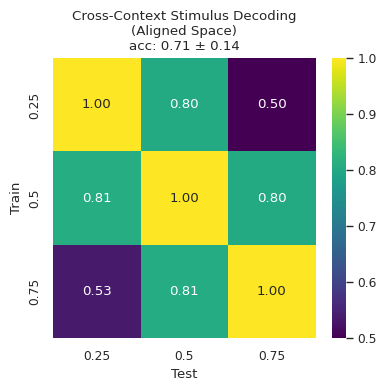

In [79]:
# Context-pairwise midpoint decoding with Logistic Regression: train on one context, test on another

# CHOOSE SETTINGS
decoding_label = ['Stimulus', 'Class'][0] 
alignment_label = ['Original Space', 'Aligned Space'][1]
decoding_target = 0.5 if decoding_label == 'Stimulus' else pca_df['boundary']
alignment = False if alignment_label == 'Original Space' else True

# set variables
n_nets, n_trials, n_units = hidden_stack.shape
contexts = sorted(pca_df['boundary'].unique())
n_contexts = len(contexts)
pairwise_acc = np.zeros((n_nets, n_contexts, n_contexts))

for net in range(n_nets):
    X = hidden_stack[net]    
    if alignment: X = align_contexts(X, pca_df['boundary'].values)

    y = (pca_df['stim'] > decoding_target).astype(int).values  # 1 if stim > decoding_target, else 0
    
    for i, ctx_train in enumerate(contexts): # train context
        train_idx = pca_df['boundary'] == ctx_train
        
        for j, ctx_test in enumerate(contexts): # test context
            test_idx = pca_df['boundary'] == ctx_test

            clf = LogisticRegression(penalty=None)
            clf.fit(X[train_idx], y[train_idx])
            acc = clf.score(X[test_idx], y[test_idx])
            pairwise_acc[net, i, j] = acc

# Average over networks
mean_net_acc = np.nanmean(pairwise_acc, axis=0)

plt.figure(figsize=(4,4))
sns.heatmap(mean_net_acc, annot=True, fmt='.2f', xticklabels=contexts, yticklabels=contexts, cmap='viridis')
plt.xlabel('Test')
plt.ylabel('Train')

offdiag = mean_net_acc[~np.eye(n_contexts, dtype=bool)]
plt.title(f'Cross-Context {decoding_label} Decoding\n({alignment_label})\nacc: {np.nanmean(offdiag):.2f} ± {np.nanstd(offdiag):.2f}')
plt.tight_layout()
plt.show()

### 2. Cross-Context Decoding in Aligned Space
Same as above, after subtracting mean context position for each context

In [14]:
# Cross-context midpoint decoding (context-aligned):
# 1. Subtract mean context (boundary) activation from each trial's hidden activation to align contexts
# 2. Decode whether stim < 0.5 or > 0.5 using these context-aligned activations
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

n_nets, n_trials, n_units = hidden_stack.shape

# Prepare context-aligned hidden activations
hidden_stack_aligned = np.empty_like(hidden_stack)
for net in range(n_nets):
    for bound in boundaries:
        idx = pca_df['boundary'] == bound
        # mean activation for this context (boundary) in this net
        context_mean = hidden_stack[net][idx].mean(axis=0)
        # subtract context mean from all trials in this context
        hidden_stack_aligned[net][idx] = hidden_stack[net][idx] - context_mean

# Now decode stim < 0.5 vs > 0.5 using context-aligned activations
midpoint = 0.5
context_aligned_decoding_accs = []
for net in range(n_nets):
    X = hidden_stack_aligned[net]  # shape: (n_trials, n_units)
    y = (pca_df['stim'] > midpoint).astype(int).values  # 1 if stim > 0.5, else 0
    clf = LogisticRegression(solver='liblinear')
    clf.fit(X, y)
    y_pred = clf.predict(X)
    acc = accuracy_score(y, y_pred)
    context_aligned_decoding_accs.append(acc)

context_aligned_decoding_accs = np.array(context_aligned_decoding_accs)
print(f"Cross-context midpoint decoding (context-aligned, stim > 0.5 vs < 0.5):\nMean = {context_aligned_decoding_accs.mean():.3f}, SD = {context_aligned_decoding_accs.std():.3f}")

Cross-context midpoint decoding (context-aligned, stim > 0.5 vs < 0.5):
Mean = 0.869, SD = 0.006
